# 04.3 — Hypothesis 3

## Positive emotion and working-memory performance

### Hypothesis

Positive emotional induction improves working-memory performance
relative to neutral and negative emotional conditions.

### Primary comparisons

1. Positive versus Neutral
2. Positive versus Negative

### Primary outcomes

1. Trial-level response accuracy.
2. Reaction time among valid correct-response trials.

### Secondary analysis

The joint accuracy and reaction-time pattern is examined to determine
whether positive emotion improves overall processing efficiency.

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats

from src import config as cfg
from src.utils import initialize_project

initialize_project()

## 3. Carregar os dados

In [2]:
analysis = pd.read_csv(
    cfg.ANALYSIS_DATASET_FILE,
    low_memory=False,
)

print(f"Full dataset: {analysis.shape}")
print(
    "Participants:",
    analysis["participant_id"].nunique(),
)

Full dataset: (17820, 63)
Participants: 23


## 4. Selecionar as três condições

<br>

Para H3 precisamos manter:

    - Positive
    - Neutral
    - Negative

porque os dois contrastes serão extraídos do mesmo conjunto.

In [3]:
h3_data = (
    analysis.loc[
        analysis["emotion_condition"].isin(
            [
                "Positive",
                "Neutral",
                "Negative",
            ]
        )
    ]
    .copy()
)

print(f"H3 dataset: {h3_data.shape}")

print(
    h3_data["emotion_condition"]
    .value_counts()
)

H3 dataset: (17820, 63)
emotion_condition
Neutral     5940
Negative    5940
Positive    5940
Name: count, dtype: int64


In [4]:
assert set(
    h3_data[
        "emotion_condition"
    ].dropna().unique()
) == {
    "Positive",
    "Neutral",
    "Negative",
}

# Auditoria da amostra

## 5. Participantes e trials

In [5]:
h3_sample = (
    h3_data
    .groupby("emotion_condition")
    .agg(
        participants=(
            "participant_id",
            "nunique",
        ),
        trials=(
            "accuracy",
            "size",
        ),
        valid_accuracy=(
            "accuracy",
            "count",
        ),
    )
    .reset_index()
)

h3_sample

,emotion_condition,participants,trials,valid_accuracy
0,Negative,22,5940,5940
1,Neutral,23,5940,5940
2,Positive,22,5940,5940


## 6. Participação nos contrastes

In [6]:
participant_conditions_h3 = (
    h3_data[
        [
            "participant_id",
            "emotion_condition",
        ]
    ]
    .drop_duplicates()
)

condition_count_h3 = (
    participant_conditions_h3
    .groupby("participant_id")
    ["emotion_condition"]
    .nunique()
)

condition_count_h3.value_counts()

emotion_condition
3    21
2     2
Name: count, dtype: int64

In [7]:
positive_ids = set(
    h3_data.loc[
        h3_data[
            "emotion_condition"
        ] == "Positive",
        "participant_id",
    ]
)

neutral_ids = set(
    h3_data.loc[
        h3_data[
            "emotion_condition"
        ] == "Neutral",
        "participant_id",
    ]
)

negative_ids = set(
    h3_data.loc[
        h3_data[
            "emotion_condition"
        ] == "Negative",
        "participant_id",
    ]
)

print(
    "Positive and Neutral:",
    len(
        positive_ids
        & neutral_ids
    ),
)

print(
    "Positive and Negative:",
    len(
        positive_ids
        & negative_ids
    ),
)

Positive and Neutral: 22
Positive and Negative: 21


# Accuracy

## 7. Estatísticas descritivas

In [8]:
accuracy_summary_h3 = (
    h3_data
    .groupby("emotion_condition")
    .agg(
        participants=(
            "participant_id",
            "nunique",
        ),
        trials=(
            "accuracy",
            "size",
        ),
        correct=(
            "accuracy",
            "sum",
        ),
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        accuracy_sd=(
            "accuracy",
            "std",
        ),
        accuracy_median=(
            "accuracy",
            "median",
        ),
    )
    .reset_index()
)

accuracy_summary_h3

,emotion_condition,participants,trials,correct,accuracy_mean,accuracy_sd,accuracy_median
0,Negative,22,5940,4978,0.838047,0.368439,1.0
1,Neutral,23,5940,5049,0.850000,0.357101,1.0
2,Positive,22,5940,5055,0.851010,0.356108,1.0


## 8. Accuracy participante × condição

In [9]:
participant_accuracy_h3 = (
    h3_data
    .groupby(
        [
            "participant_id",
            "emotion_condition",
        ]
    )
    ["accuracy"]
    .mean()
    .reset_index()
)

participant_accuracy_h3.head()

,participant_id,emotion_condition,accuracy
0,1101,Negative,0.870370
1,1101,Neutral,0.870370
2,1101,Positive,0.892593
3,1106,Negative,0.822222
4,1106,Neutral,0.840741


## 9. Figura de accuracy

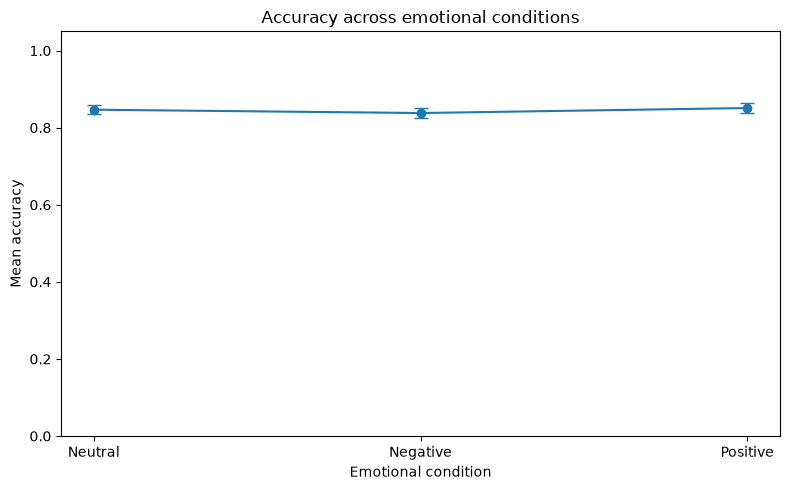

In [10]:
accuracy_plot_h3 = (
    participant_accuracy_h3
    .groupby("emotion_condition")
    ["accuracy"]
    .agg(["mean", "sem"])
    .reindex(
        [
            "Neutral",
            "Negative",
            "Positive",
        ]
    )
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.errorbar(
    accuracy_plot_h3[
        "emotion_condition"
    ],
    accuracy_plot_h3[
        "mean"
    ],
    yerr=accuracy_plot_h3[
        "sem"
    ],
    marker="o",
    capsize=5,
)

ax.set_xlabel(
    "Emotional condition"
)

ax.set_ylabel(
    "Mean accuracy"
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_title(
    "Accuracy across emotional conditions"
)

fig.tight_layout()

plt.show()

# Accuracy — Positive vs Neutral

## 10. GEE com Neutral como referência

In [11]:
accuracy_formula_neutral_h3 = (
    "accuracy ~ "
    "C(emotion_condition, "
    "Treatment(reference='Neutral'))"
)

accuracy_model_neutral_h3 = (
    smf.gee(
        formula=(
            accuracy_formula_neutral_h3
        ),
        groups="participant_id",
        data=h3_data,
        family=(
            sm.families.Binomial()
        ),
        cov_struct=(
            sm.cov_struct.Exchangeable()
        ),
    )
    .fit()
)

print(
    accuracy_model_neutral_h3.summary()
)

                               GEE Regression Results                              
Dep. Variable:                    accuracy   No. Observations:                17820
Model:                                 GEE   No. clusters:                       23
Method:                        Generalized   Min. cluster size:                 405
                      Estimating Equations   Max. cluster size:                 810
Family:                           Binomial   Mean cluster size:               774.8
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Fri, 07 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         13:55:42
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------

## 11. Extrair tabela do modelo

In [12]:
def extract_gee_results(
    result,
):
    confidence = (
        result.conf_int()
    )

    table = pd.DataFrame(
        {
            "term":
                result.params.index,

            "beta":
                result.params.values,

            "se":
                result.bse.values,

            "z":
                result.tvalues.values,

            "p":
                result.pvalues.values,

            "ci_low":
                confidence.iloc[
                    :, 0
                ].values,

            "ci_high":
                confidence.iloc[
                    :, 1
                ].values,
        }
    )

    table[
        "odds_ratio"
    ] = np.exp(
        table["beta"]
    )

    table[
        "or_ci_low"
    ] = np.exp(
        table["ci_low"]
    )

    table[
        "or_ci_high"
    ] = np.exp(
        table["ci_high"]
    )

    return table

In [13]:
accuracy_results_neutral_h3 = (
    extract_gee_results(
        accuracy_model_neutral_h3
    )
)

accuracy_results_neutral_h3

,term,beta,se,z,p,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
0,Intercept,1.717139,0.081404,21.094125,9.005550e-99,1.557591,1.876687,5.568574,4.747370,6.531830
1,"C(emotion_condition, Treatment(reference='Neut...",-0.084124,0.064066,-1.313073,1.891584e-01,-0.209691,0.041444,0.919318,0.810835,1.042315
2,"C(emotion_condition, Treatment(reference='Neut...",0.001511,0.056789,0.026611,9.787704e-01,-0.109793,0.112815,1.001512,0.896020,1.119425


In [14]:
accuracy_positive_neutral_h3 = (
    accuracy_results_neutral_h3.loc[
        accuracy_results_neutral_h3[
            "term"
        ].str.contains(
            "Positive",
            regex=False,
        )
    ]
    .copy()
)

accuracy_positive_neutral_h3

,term,beta,se,z,p,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
2,"C(emotion_condition, Treatment(reference='Neut...",0.001511,0.056789,0.026611,0.97877,-0.109793,0.112815,1.001512,0.89602,1.119425


# Accuracy — Positive vs Negative

## 12. GEE com Negative como referência

In [15]:
accuracy_formula_negative_h3 = (
    "accuracy ~ "
    "C(emotion_condition, "
    "Treatment(reference='Negative'))"
)

accuracy_model_negative_h3 = (
    smf.gee(
        formula=(
            accuracy_formula_negative_h3
        ),
        groups="participant_id",
        data=h3_data,
        family=(
            sm.families.Binomial()
        ),
        cov_struct=(
            sm.cov_struct.Exchangeable()
        ),
    )
    .fit()
)

print(
    accuracy_model_negative_h3.summary()
)

                               GEE Regression Results                              
Dep. Variable:                    accuracy   No. Observations:                17820
Model:                                 GEE   No. clusters:                       23
Method:                        Generalized   Min. cluster size:                 405
                      Estimating Equations   Max. cluster size:                 810
Family:                           Binomial   Mean cluster size:               774.8
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Fri, 07 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         13:55:42
                                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------

In [16]:
accuracy_results_negative_h3 = (
    extract_gee_results(
        accuracy_model_negative_h3
    )
)

accuracy_positive_negative_h3 = (
    accuracy_results_negative_h3.loc[
        accuracy_results_negative_h3[
            "term"
        ].str.contains(
            "Positive",
            regex=False,
        )
    ]
    .copy()
)

accuracy_positive_negative_h3

,term,beta,se,z,p,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
2,"C(emotion_condition, Treatment(reference='Nega...",0.085635,0.057528,1.488582,0.136598,-0.027118,0.198387,1.089408,0.973247,1.219434


## 13. Consolidar os contrastes de accuracy

In [17]:
accuracy_positive_neutral_h3[
    "contrast"
] = "Positive vs Neutral"

accuracy_positive_negative_h3[
    "contrast"
] = "Positive vs Negative"

accuracy_contrasts_h3 = pd.concat(
    [
        accuracy_positive_neutral_h3,
        accuracy_positive_negative_h3,
    ],
    ignore_index=True,
)

accuracy_contrasts_h3[
    [
        "contrast",
        "beta",
        "se",
        "z",
        "p",
        "odds_ratio",
        "or_ci_low",
        "or_ci_high",
    ]
]

,contrast,beta,se,z,p,odds_ratio,or_ci_low,or_ci_high
0,Positive vs Neutral,0.001511,0.056789,0.026611,0.978770,1.001512,0.896020,1.119425
1,Positive vs Negative,0.085635,0.057528,1.488582,0.136598,1.089408,0.973247,1.219434


# Reaction Time

## 14. Construir a base analítica

In [18]:
rt_h3 = (
    h3_data.loc[
        (
            h3_data[
                "accuracy"
            ] == 1
        )
        &
        (
            h3_data[
                "rt_valid"
            ] == True
        )
    ]
    .copy()
)

rt_h3[
    "log_rt"
] = np.log(
    rt_h3[
        "reaction_time_ms"
    ]
)

print(
    "RT observations:",
    len(rt_h3),
)

print(
    "RT participants:",
    rt_h3[
        "participant_id"
    ].nunique(),
)

RT observations: 14184
RT participants: 23


## 15. Estatísticas descritivas de RT

In [19]:
rt_summary_h3 = (
    rt_h3
    .groupby("emotion_condition")
    .agg(
        participants=(
            "participant_id",
            "nunique",
        ),
        trials=(
            "reaction_time_ms",
            "size",
        ),
        mean_rt=(
            "reaction_time_ms",
            "mean",
        ),
        sd_rt=(
            "reaction_time_ms",
            "std",
        ),
        median_rt=(
            "reaction_time_ms",
            "median",
        ),
        mean_log_rt=(
            "log_rt",
            "mean",
        ),
    )
    .reset_index()
)

rt_summary_h3

,emotion_condition,participants,trials,mean_rt,sd_rt,median_rt,mean_log_rt
0,Negative,22,4704,740.248724,744.225627,433.5,6.249127
1,Neutral,23,4829,966.584593,896.358283,630.0,6.511630
2,Positive,22,4651,771.327456,808.863264,421.0,6.243021


## 16. RT participante × condição

In [20]:
participant_rt_h3 = (
    rt_h3
    .groupby(
        [
            "participant_id",
            "emotion_condition",
        ]
    )
    .agg(
        mean_rt=(
            "reaction_time_ms",
            "mean",
        ),
        median_rt=(
            "reaction_time_ms",
            "median",
        ),
        mean_log_rt=(
            "log_rt",
            "mean",
        ),
    )
    .reset_index()
)

participant_rt_h3.head()

,participant_id,emotion_condition,mean_rt,median_rt,mean_log_rt
0,1101,Negative,690.798246,461.0,6.237602
1,1101,Neutral,696.746725,437.0,6.216401
2,1101,Positive,475.032864,298.0,5.867209
3,1106,Negative,559.733010,356.0,6.047027
4,1106,Neutral,627.085586,473.0,6.212370


## 17. Figura de RT

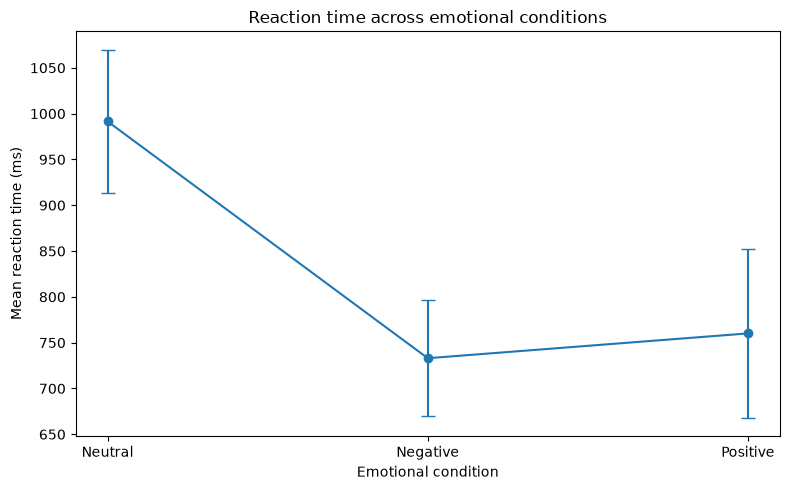

In [21]:
rt_plot_h3 = (
    participant_rt_h3
    .groupby("emotion_condition")
    ["mean_rt"]
    .agg(["mean", "sem"])
    .reindex(
        [
            "Neutral",
            "Negative",
            "Positive",
        ]
    )
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.errorbar(
    rt_plot_h3[
        "emotion_condition"
    ],
    rt_plot_h3[
        "mean"
    ],
    yerr=rt_plot_h3[
        "sem"
    ],
    marker="o",
    capsize=5,
)

ax.set_xlabel(
    "Emotional condition"
)

ax.set_ylabel(
    "Mean reaction time (ms)"
)

ax.set_title(
    "Reaction time across emotional conditions"
)

fig.tight_layout()

plt.show()

# RT — Positive vs Neutral

## 18. Mixed model com Neutral como referência

In [22]:
rt_formula_neutral_h3 = (
    "log_rt ~ "
    "C(emotion_condition, "
    "Treatment(reference='Neutral'))"
)

rt_model_neutral_h3 = (
    smf.mixedlm(
        formula=(
            rt_formula_neutral_h3
        ),
        data=rt_h3,
        groups=rt_h3[
            "participant_id"
        ],
    )
)

rt_result_neutral_h3 = (
    rt_model_neutral_h3
    .fit(
        reml=False
    )
)

print(
    rt_result_neutral_h3.summary()
)

                                   Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  log_rt     
No. Observations:                  14184                    Method:                              ML         
No. Groups:                        23                       Scale:                               0.5543     
Min. group size:                   292                      Log-Likelihood:                      -16000.0149
Max. group size:                   723                      Converged:                           Yes        
Mean group size:                   616.7                                                                    
------------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------

## 19. Função para extrair resultados MixedLM

In [23]:
def extract_mixed_results(
    result,
):
    confidence = (
        result.conf_int()
    )

    table = pd.DataFrame(
        {
            "term":
                result.params.index,

            "beta":
                result.params.values,

            "se":
                result.bse.values,

            "z":
                result.tvalues.values,

            "p":
                result.pvalues.values,

            "ci_low":
                confidence.iloc[
                    :, 0
                ].values,

            "ci_high":
                confidence.iloc[
                    :, 1
                ].values,
        }
    )

    table[
        "rt_ratio"
    ] = np.exp(
        table["beta"]
    )

    table[
        "percent_change"
    ] = (
        np.exp(
            table["beta"]
        )
        - 1
    ) * 100

    table[
        "percent_ci_low"
    ] = (
        np.exp(
            table["ci_low"]
        )
        - 1
    ) * 100

    table[
        "percent_ci_high"
    ] = (
        np.exp(
            table["ci_high"]
        )
        - 1
    ) * 100

    return table

In [24]:
rt_results_neutral_h3 = (
    extract_mixed_results(
        rt_result_neutral_h3
    )
)

rt_positive_neutral_h3 = (
    rt_results_neutral_h3.loc[
        rt_results_neutral_h3[
            "term"
        ].str.contains(
            "Positive",
            regex=False,
        )
    ]
    .copy()
)

rt_positive_neutral_h3

,term,beta,se,z,p,ci_low,ci_high,rt_ratio,percent_change,percent_ci_low,percent_ci_high
2,"C(emotion_condition, Treatment(reference='Neut...",-0.285438,0.015348,-18.598212,3.322041e-77,-0.315519,-0.255357,0.751685,-24.831501,-27.058956,-22.536025


# RT — Positive vs Negative

## 20. Mixed model com Negative como referência

In [25]:
rt_formula_negative_h3 = (
    "log_rt ~ "
    "C(emotion_condition, "
    "Treatment(reference='Negative'))"
)

rt_model_negative_h3 = (
    smf.mixedlm(
        formula=(
            rt_formula_negative_h3
        ),
        data=rt_h3,
        groups=rt_h3[
            "participant_id"
        ],
    )
)

rt_result_negative_h3 = (
    rt_model_negative_h3
    .fit(
        reml=False
    )
)

print(
    rt_result_negative_h3.summary()
)

                                   Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  log_rt     
No. Observations:                  14184                    Method:                              ML         
No. Groups:                        23                       Scale:                               0.5543     
Min. group size:                   292                      Log-Likelihood:                      -16000.0149
Max. group size:                   723                      Converged:                           Yes        
Mean group size:                   616.7                                                                    
------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------

In [26]:
rt_results_negative_h3 = (
    extract_mixed_results(
        rt_result_negative_h3
    )
)

rt_positive_negative_h3 = (
    rt_results_negative_h3.loc[
        rt_results_negative_h3[
            "term"
        ].str.contains(
            "Positive",
            regex=False,
        )
    ]
    .copy()
)

rt_positive_negative_h3

,term,beta,se,z,p,ci_low,ci_high,rt_ratio,percent_change,percent_ci_low,percent_ci_high
2,"C(emotion_condition, Treatment(reference='Nega...",-0.020465,0.015631,-1.309285,0.190438,-0.051102,0.010171,0.979743,-2.025749,-4.981803,1.022269


## 21. Consolidar os contrastes de RT

In [27]:
rt_positive_neutral_h3[
    "contrast"
] = "Positive vs Neutral"

rt_positive_negative_h3[
    "contrast"
] = "Positive vs Negative"

rt_contrasts_h3 = pd.concat(
    [
        rt_positive_neutral_h3,
        rt_positive_negative_h3,
    ],
    ignore_index=True,
)

rt_contrasts_h3[
    [
        "contrast",
        "beta",
        "se",
        "z",
        "p",
        "percent_change",
        "percent_ci_low",
        "percent_ci_high",
    ]
]

,contrast,beta,se,z,p,percent_change,percent_ci_low,percent_ci_high
0,Positive vs Neutral,-0.285438,0.015348,-18.598212,3.322041e-77,-24.831501,-27.058956,-22.536025
1,Positive vs Negative,-0.020465,0.015631,-1.309285,1.904378e-01,-2.025749,-4.981803,1.022269


# Processing efficiency

## 20. Mixed model com Negative como referência

In [28]:
rt_formula_negative_h3 = (
    "log_rt ~ "
    "C(emotion_condition, "
    "Treatment(reference='Negative'))"
)

rt_model_negative_h3 = (
    smf.mixedlm(
        formula=(
            rt_formula_negative_h3
        ),
        data=rt_h3,
        groups=rt_h3[
            "participant_id"
        ],
    )
)

rt_result_negative_h3 = (
    rt_model_negative_h3
    .fit(
        reml=False
    )
)

print(
    rt_result_negative_h3.summary()
)

                                   Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  log_rt     
No. Observations:                  14184                    Method:                              ML         
No. Groups:                        23                       Scale:                               0.5543     
Min. group size:                   292                      Log-Likelihood:                      -16000.0149
Max. group size:                   723                      Converged:                           Yes        
Mean group size:                   616.7                                                                    
------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------

In [29]:
rt_results_negative_h3 = (
    extract_mixed_results(
        rt_result_negative_h3
    )
)

rt_positive_negative_h3 = (
    rt_results_negative_h3.loc[
        rt_results_negative_h3[
            "term"
        ].str.contains(
            "Positive",
            regex=False,
        )
    ]
    .copy()
)

rt_positive_negative_h3

,term,beta,se,z,p,ci_low,ci_high,rt_ratio,percent_change,percent_ci_low,percent_ci_high
2,"C(emotion_condition, Treatment(reference='Nega...",-0.020465,0.015631,-1.309285,0.190438,-0.051102,0.010171,0.979743,-2.025749,-4.981803,1.022269


## 21. Consolidar os contrastes de RT

In [30]:
rt_positive_neutral_h3[
    "contrast"
] = "Positive vs Neutral"

rt_positive_negative_h3[
    "contrast"
] = "Positive vs Negative"

rt_contrasts_h3 = pd.concat(
    [
        rt_positive_neutral_h3,
        rt_positive_negative_h3,
    ],
    ignore_index=True,
)

rt_contrasts_h3[
    [
        "contrast",
        "beta",
        "se",
        "z",
        "p",
        "percent_change",
        "percent_ci_low",
        "percent_ci_high",
    ]
]

,contrast,beta,se,z,p,percent_change,percent_ci_low,percent_ci_high
0,Positive vs Neutral,-0.285438,0.015348,-18.598212,3.322041e-77,-24.831501,-27.058956,-22.536025
1,Positive vs Negative,-0.020465,0.015631,-1.309285,1.904378e-01,-2.025749,-4.981803,1.022269


# Processing efficiency

## 22. Construir base participante × condição

In [31]:
participant_performance_h3 = (
    participant_accuracy_h3
    .merge(
        participant_rt_h3[
            [
                "participant_id",
                "emotion_condition",
                "mean_rt",
                "median_rt",
            ]
        ],
        on=[
            "participant_id",
            "emotion_condition",
        ],
        how="left",
        validate="one_to_one",
    )
)

In [32]:
participant_performance_h3[
    "inverse_efficiency"
] = (
    participant_performance_h3[
        "mean_rt"
    ]
    /
    participant_performance_h3[
        "accuracy"
    ]
)

participant_performance_h3.head()

,participant_id,emotion_condition,accuracy,mean_rt,median_rt,inverse_efficiency
0,1101,Negative,0.870370,690.798246,461.0,793.683091
1,1101,Neutral,0.870370,696.746725,437.0,800.517514
2,1101,Positive,0.892593,475.032864,298.0,532.194495
3,1106,Negative,0.822222,559.733010,356.0,680.756363
4,1106,Neutral,0.840741,627.085586,473.0,745.872723


## 23. Descrever eficiência

In [33]:
efficiency_summary_h3 = (
    participant_performance_h3
    .groupby("emotion_condition")
    .agg(
        n=(
            "participant_id",
            "count",
        ),
        mean_accuracy=(
            "accuracy",
            "mean",
        ),
        mean_rt=(
            "mean_rt",
            "mean",
        ),
        mean_ies=(
            "inverse_efficiency",
            "mean",
        ),
        sd_ies=(
            "inverse_efficiency",
            "std",
        ),
    )
    .reset_index()
)

efficiency_summary_h3

,emotion_condition,n,mean_accuracy,mean_rt,mean_ies,sd_ies
0,Negative,22,0.838047,733.013526,875.113822,342.301087
1,Neutral,23,0.846699,991.486311,1184.090140,481.792595
2,Positive,22,0.851010,760.094841,899.419206,510.136170


# IES — Positive vs Neutral

## 24. Comparação pareada

In [34]:
ies_wide_h3 = (
    participant_performance_h3
    .pivot_table(
        index="participant_id",
        columns="emotion_condition",
        values="inverse_efficiency",
        aggfunc="first",
    )
)

**Positive vs Neutral:**

In [35]:
ies_positive_neutral = (
    ies_wide_h3[
        [
            "Positive",
            "Neutral",
        ]
    ]
    .dropna()
)

ies_test_positive_neutral = (
    stats.ttest_rel(
        ies_positive_neutral[
            "Positive"
        ],
        ies_positive_neutral[
            "Neutral"
        ],
    )
)

ies_test_positive_neutral

TtestResult(statistic=np.float64(-4.38451583484968), pvalue=np.float64(0.0002590800571682766), df=np.int64(21))

**Positive vs Negative:**

In [36]:
ies_positive_negative = (
    ies_wide_h3[
        [
            "Positive",
            "Negative",
        ]
    ]
    .dropna()
)

ies_test_positive_negative = (
    stats.ttest_rel(
        ies_positive_negative[
            "Positive"
        ],
        ies_positive_negative[
            "Negative"
        ],
    )
)

ies_test_positive_negative

TtestResult(statistic=np.float64(0.20584056585921348), pvalue=np.float64(0.8389962628897517), df=np.int64(20))

## 25. Consolidar IES

In [37]:
ies_results_h3 = pd.DataFrame(
    [
        {
            "contrast":
                "Positive vs Neutral",

            "n":
                len(
                    ies_positive_neutral
                ),

            "positive_mean":
                ies_positive_neutral[
                    "Positive"
                ].mean(),

            "comparator_mean":
                ies_positive_neutral[
                    "Neutral"
                ].mean(),

            "mean_difference":
                (
                    ies_positive_neutral[
                        "Positive"
                    ]
                    -
                    ies_positive_neutral[
                        "Neutral"
                    ]
                ).mean(),

            "t":
                ies_test_positive_neutral.statistic,

            "p":
                ies_test_positive_neutral.pvalue,
        },
        {
            "contrast":
                "Positive vs Negative",

            "n":
                len(
                    ies_positive_negative
                ),

            "positive_mean":
                ies_positive_negative[
                    "Positive"
                ].mean(),

            "comparator_mean":
                ies_positive_negative[
                    "Negative"
                ].mean(),

            "mean_difference":
                (
                    ies_positive_negative[
                        "Positive"
                    ]
                    -
                    ies_positive_negative[
                        "Negative"
                    ]
                ).mean(),

            "t":
                ies_test_positive_negative.statistic,

            "p":
                ies_test_positive_negative.pvalue,
        },
    ]
)

ies_results_h3

,contrast,n,positive_mean,comparator_mean,mean_difference,t,p
0,Positive vs Neutral,22,899.419206,1126.672137,-227.252931,-4.384516,0.000259
1,Positive vs Negative,21,869.785653,851.739730,18.045923,0.205841,0.838996


Um IES menor na condição positiva indica melhor eficiência combinada.

## Decision rules

Hypothesis 3 is supported if positive emotion is associated with:

- significantly higher accuracy than both neutral and negative emotion;
- significantly faster reaction time without reduced accuracy;
- or significantly better processing efficiency relative to both
  comparison conditions.

Hypothesis 3 is partially supported if:

- positive emotion improves performance relative to only one comparator;
- or improvement is observed in only one outcome;
- or positive emotion produces faster responses without a statistically
  detectable accuracy advantage.

Hypothesis 3 is not supported if:

- positive emotion does not improve accuracy or reaction time relative
  to either comparator;
- or any apparent speed advantage is accompanied by a reliable loss of
  accuracy.

# Decisão programática

## 27. Extrair os valores principais

In [38]:
acc_pn = (
    accuracy_positive_neutral_h3
    .iloc[0]
)

acc_pg = (
    accuracy_positive_negative_h3
    .iloc[0]
)

rt_pn = (
    rt_positive_neutral_h3
    .iloc[0]
)

rt_pg = (
    rt_positive_negative_h3
    .iloc[0]
)

acc_pg: representa Positive vs Negative.

## 28. Definir os padrões

In [39]:
accuracy_better_neutral = (
    acc_pn["p"] < cfg.ALPHA
    and acc_pn["beta"] > 0
)

accuracy_better_negative = (
    acc_pg["p"] < cfg.ALPHA
    and acc_pg["beta"] > 0
)

rt_faster_neutral = (
    rt_pn["p"] < cfg.ALPHA
    and rt_pn["beta"] < 0
)

rt_faster_negative = (
    rt_pg["p"] < cfg.ALPHA
    and rt_pg["beta"] < 0
)

## 29. Avaliação da hipótese

In [40]:
benefit_vs_neutral = (
    accuracy_better_neutral
    or rt_faster_neutral
)

benefit_vs_negative = (
    accuracy_better_negative
    or rt_faster_negative
)

if (
    benefit_vs_neutral
    and benefit_vs_negative
):
    h3_assessment = "supported"

elif (
    benefit_vs_neutral
    or benefit_vs_negative
):
    h3_assessment = "partially supported"

else:
    h3_assessment = "not supported"

In [41]:
accuracy_supported = (
    accuracy_better_neutral
    or accuracy_better_negative
)

rt_supported = (
    rt_faster_neutral
    or rt_faster_negative
)

if (
    accuracy_better_neutral
    and accuracy_better_negative
):
    h3_assessment = "supported"

elif (
    rt_faster_neutral
    and rt_faster_negative
    and not accuracy_supported
):
    h3_assessment = "partially supported"

elif (
    benefit_vs_neutral
    or benefit_vs_negative
):
    h3_assessment = "partially supported"

else:
    h3_assessment = "not supported"

In [42]:
print(
    "Hypothesis 3 assessment:",
    h3_assessment,
)

Hypothesis 3 assessment: partially supported


# Exportar resultados

## 30. Criar diretório

In [43]:
h3_output_dir = (
    cfg.TABLES_DIR
    / "hypothesis_03"
)

h3_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

## 31. Salvar tabelas

In [44]:
h3_sample.to_csv(
    h3_output_dir
    / "h3_sample.csv",
    index=False,
)

accuracy_summary_h3.to_csv(
    h3_output_dir
    / "h3_accuracy_descriptive.csv",
    index=False,
)

accuracy_contrasts_h3.to_csv(
    h3_output_dir
    / "h3_accuracy_models.csv",
    index=False,
)

rt_summary_h3.to_csv(
    h3_output_dir
    / "h3_rt_descriptive.csv",
    index=False,
)

rt_contrasts_h3.to_csv(
    h3_output_dir
    / "h3_rt_models.csv",
    index=False,
)

efficiency_summary_h3.to_csv(
    h3_output_dir
    / "h3_efficiency_descriptive.csv",
    index=False,
)

ies_results_h3.to_csv(
    h3_output_dir
    / "h3_efficiency_tests.csv",
    index=False,
)

## 32. Resumo da hipótese

In [45]:
h3_summary = pd.DataFrame(
    {
        "hypothesis": [
            "H3"
        ],

        "participants": [
            h3_data[
                "participant_id"
            ].nunique()
        ],

        "accuracy_observations": [
            len(h3_data)
        ],

        "rt_observations": [
            len(rt_h3)
        ],

        "positive_neutral_accuracy_or": [
            acc_pn[
                "odds_ratio"
            ]
        ],

        "positive_neutral_accuracy_p": [
            acc_pn["p"]
        ],

        "positive_negative_accuracy_or": [
            acc_pg[
                "odds_ratio"
            ]
        ],

        "positive_negative_accuracy_p": [
            acc_pg["p"]
        ],

        "positive_neutral_rt_change": [
            rt_pn[
                "percent_change"
            ]
        ],

        "positive_neutral_rt_p": [
            rt_pn["p"]
        ],

        "positive_negative_rt_change": [
            rt_pg[
                "percent_change"
            ]
        ],

        "positive_negative_rt_p": [
            rt_pg["p"]
        ],

        "assessment": [
            h3_assessment
        ],
    }
)

h3_summary.to_csv(
    h3_output_dir
    / "h3_summary.csv",
    index=False,
)

h3_summary

,hypothesis,participants,accuracy_observations,rt_observations,positive_neutral_accuracy_or,positive_neutral_accuracy_p,positive_negative_accuracy_or,positive_negative_accuracy_p,positive_neutral_rt_change,positive_neutral_rt_p,positive_negative_rt_change,positive_negative_rt_p,assessment
0,H3,23,17820,14184,1.001512,0.97877,1.089408,0.136598,-24.831501,3.322041e-77,-2.025749,0.190438,partially supported


## Report export validation
Validate exported H3 report schemas.


In [46]:
expected={
 "sample":h3_output_dir/"h3_sample.csv",
 "accuracy_descriptive":h3_output_dir/"h3_accuracy_descriptive.csv",
 "accuracy_models":h3_output_dir/"h3_accuracy_models.csv",
 "rt_descriptive":h3_output_dir/"h3_rt_descriptive.csv",
 "rt_models":h3_output_dir/"h3_rt_models.csv",
 "efficiency_descriptive":h3_output_dir/"h3_efficiency_descriptive.csv",
 "efficiency_tests":h3_output_dir/"h3_efficiency_tests.csv",
 "summary":h3_output_dir/"h3_summary.csv",
}
print("="*72)
print("H3 REPORT EXPORT VALIDATION")
print("="*72)
import pandas as pd
for k,p in expected.items():
 print(f"{k:<24}", "OK" if p.exists() else "MISSING", p.name)
 if p.exists():
  print(" ", pd.read_csv(p,nrows=1).columns.tolist())


H3 REPORT EXPORT VALIDATION
sample                   OK h3_sample.csv
  ['emotion_condition', 'participants', 'trials', 'valid_accuracy']
accuracy_descriptive     OK h3_accuracy_descriptive.csv
  ['emotion_condition', 'participants', 'trials', 'correct', 'accuracy_mean', 'accuracy_sd', 'accuracy_median']
accuracy_models          OK h3_accuracy_models.csv
  ['term', 'beta', 'se', 'z', 'p', 'ci_low', 'ci_high', 'odds_ratio', 'or_ci_low', 'or_ci_high', 'contrast']
rt_descriptive           OK h3_rt_descriptive.csv
  ['emotion_condition', 'participants', 'trials', 'mean_rt', 'sd_rt', 'median_rt', 'mean_log_rt']
rt_models                OK h3_rt_models.csv
  ['term', 'beta', 'se', 'z', 'p', 'ci_low', 'ci_high', 'rt_ratio', 'percent_change', 'percent_ci_low', 'percent_ci_high', 'contrast']
efficiency_descriptive   OK h3_efficiency_descriptive.csv
  ['emotion_condition', 'n', 'mean_accuracy', 'mean_rt', 'mean_ies', 'sd_ies']
efficiency_tests         OK h3_efficiency_tests.csv
  ['contrast', 'n

# Última célula: resumo da analise

In [47]:
positive_accuracy = (
    accuracy_summary_h3.loc[
        accuracy_summary_h3[
            "emotion_condition"
        ] == "Positive",
        "accuracy_mean",
    ]
    .iloc[0]
)

neutral_accuracy = (
    accuracy_summary_h3.loc[
        accuracy_summary_h3[
            "emotion_condition"
        ] == "Neutral",
        "accuracy_mean",
    ]
    .iloc[0]
)

negative_accuracy = (
    accuracy_summary_h3.loc[
        accuracy_summary_h3[
            "emotion_condition"
        ] == "Negative",
        "accuracy_mean",
    ]
    .iloc[0]
)

In [48]:
print("=" * 75)
print("HYPOTHESIS 3 ANALYSIS SUMMARY")
print("=" * 75)

print(
    f"Participants: "
    f"{h3_data['participant_id'].nunique()}"
)

print(
    f"Accuracy observations: "
    f"{len(h3_data)}"
)

print(
    f"RT observations: "
    f"{len(rt_h3)}"
)

print()

print(
    f"Positive accuracy: "
    f"{positive_accuracy:.3f}"
)

print(
    f"Neutral accuracy: "
    f"{neutral_accuracy:.3f}"
)

print(
    f"Negative accuracy: "
    f"{negative_accuracy:.3f}"
)

print()

print(
    "Positive vs Neutral accuracy OR: "
    f"{acc_pn['odds_ratio']:.3f}"
)

print(
    "Positive vs Neutral accuracy p: "
    f"{acc_pn['p']:.4f}"
)

print(
    "Positive vs Negative accuracy OR: "
    f"{acc_pg['odds_ratio']:.3f}"
)

print(
    "Positive vs Negative accuracy p: "
    f"{acc_pg['p']:.4f}"
)

print()

print(
    "Positive vs Neutral RT change: "
    f"{rt_pn['percent_change']:.1f}%"
)

print(
    "Positive vs Neutral RT p: "
    f"{rt_pn['p']:.4f}"
)

print(
    "Positive vs Negative RT change: "
    f"{rt_pg['percent_change']:.1f}%"
)

print(
    "Positive vs Negative RT p: "
    f"{rt_pg['p']:.4f}"
)

print()

print(
    f"H3 assessment: "
    f"{h3_assessment}"
)

print("=" * 75)

HYPOTHESIS 3 ANALYSIS SUMMARY
Participants: 23
Accuracy observations: 17820
RT observations: 14184

Positive accuracy: 0.851
Neutral accuracy: 0.850
Negative accuracy: 0.838

Positive vs Neutral accuracy OR: 1.002
Positive vs Neutral accuracy p: 0.9788
Positive vs Negative accuracy OR: 1.089
Positive vs Negative accuracy p: 0.1366

Positive vs Neutral RT change: -24.8%
Positive vs Neutral RT p: 0.0000
Positive vs Negative RT change: -2.0%
Positive vs Negative RT p: 0.1904

H3 assessment: partially supported
